# Импорт библиотек

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, roc_curve, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
import warnings

# Игнорируем предупреждения
warnings.filterwarnings("ignore")

# Данные

In [2]:
train_data = pd.read_csv('/kaggle/input/playground-series-s4e10/train.csv')
test_data = pd.read_csv('/kaggle/input/playground-series-s4e10/test.csv')

In [3]:
def summarize_dataframe(dataframe):
    stats = dataframe.describe(include='all').T  # Транспонирование для удобства
    stats = stats.assign(
        missing_values=dataframe.isna().sum(),  # Подсчет пропущенных значений
        unique_values=dataframe.nunique()       # Подсчет уникальных значений
    )
    return stats

In [4]:
train_summary = summarize_dataframe(train_data)
print("train_data summary")
train_summary

train_data summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max,missing_values,unique_values
id,58645.0,NaN,NaN,NaN,29322.0,16929.497605,0.0,14661.0,29322.0,43983.0,58644.0,0,58645
person_age,58645.0,NaN,NaN,NaN,27.550857,6.033216,20.0,23.0,26.0,30.0,123.0,0,53
person_income,58645.0,NaN,NaN,NaN,64046.172871,37931.106979,4200.0,42000.0,58000.0,75600.0,1900000.0,0,2641
person_home_ownership,58645,4,RENT,30594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4
person_emp_length,58645.0,NaN,NaN,NaN,4.701015,3.959784,0.0,2.0,4.0,7.0,123.0,0,36
loan_intent,58645,6,EDUCATION,12271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,6
loan_grade,58645,7,A,20984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,7
loan_amnt,58645.0,NaN,NaN,NaN,9217.556518,5563.807384,500.0,5000.0,8000.0,12000.0,35000.0,0,545
loan_int_rate,58645.0,NaN,NaN,NaN,10.677874,3.034697,5.42,7.88,10.75,12.99,23.22,0,362
loan_percent_income,58645.0,NaN,NaN,NaN,0.159238,0.091692,0.0,0.09,0.14,0.21,0.83,0,61


In [5]:
test_summary = summarize_dataframe(test_data)
print("test_data summary")
train_summary

test_data summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max,missing_values,unique_values
id,58645.0,NaN,NaN,NaN,29322.0,16929.497605,0.0,14661.0,29322.0,43983.0,58644.0,0,58645
person_age,58645.0,NaN,NaN,NaN,27.550857,6.033216,20.0,23.0,26.0,30.0,123.0,0,53
person_income,58645.0,NaN,NaN,NaN,64046.172871,37931.106979,4200.0,42000.0,58000.0,75600.0,1900000.0,0,2641
person_home_ownership,58645,4,RENT,30594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4
person_emp_length,58645.0,NaN,NaN,NaN,4.701015,3.959784,0.0,2.0,4.0,7.0,123.0,0,36
loan_intent,58645,6,EDUCATION,12271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,6
loan_grade,58645,7,A,20984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,7
loan_amnt,58645.0,NaN,NaN,NaN,9217.556518,5563.807384,500.0,5000.0,8000.0,12000.0,35000.0,0,545
loan_int_rate,58645.0,NaN,NaN,NaN,10.677874,3.034697,5.42,7.88,10.75,12.99,23.22,0,362
loan_percent_income,58645.0,NaN,NaN,NaN,0.159238,0.091692,0.0,0.09,0.14,0.21,0.83,0,61


In [6]:
def encode_categorical_columns(df, cols):
    return df.assign(**{col: pd.Categorical(df[col]).codes for col in cols})

columns = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

train_data_2 = encode_categorical_columns(train_data, columns)
test_data_2 = encode_categorical_columns(test_data, columns)

In [7]:
# Функция для категоризации дохода
def categorize_income(income):
    return (
        "Низкий доход" if income <= 50000 else
        "Средний доход" if income <= 500000 else
        "Высокий доход"
    )

# Применение категоризации для обоих датасетов
for df in [train_data_2, test_data_2]:
    df["income_category"] = df["person_income"].apply(categorize_income)

# Функция для кодирования категориальных столбцов
def encode_categorical_columns(df, cols):
    return df.assign(**{col: pd.Categorical(df[col]).codes for col in cols})

# Кодирование категориального признака "income_category"
train_data_2 = encode_categorical_columns(train_data_2, ["income_category"])
test_data_2 = encode_categorical_columns(test_data_2, ["income_category"])

# Вывод первых пяти строк с доходом и его категорией
print(train_data_2[["person_income", "income_category"]].head())

   person_income  income_category
0          35000                1
1          56000                2
2          28800                1
3          70000                2
4          60000                2


In [8]:
# Объединяем train_data_2 и test_data_2
combined_data = pd.concat([train_data_2, test_data_2], axis=0, ignore_index=True)

def calculate_probabilities(data):
    """
    Вычисляем вероятность положительного значения loan_status для каждого loan_grade.
    """
    # Группируем данные по loan_grade и вычисляем среднее значение loan_status
    probabilities = data.groupby('loan_grade')['loan_status'].mean().reset_index()
    # Переименовываем столбец для удобства
    probabilities.rename(columns={'loan_status': 'probability_positive'}, inplace=True)
    return probabilities

# Вычисляем вероятности положительного значения loan_status для каждого loan_grade
loan_grade_probabilities = calculate_probabilities(combined_data)

# Объединяем вероятности обратно в основной DataFrame
combined_data = combined_data.merge(loan_grade_probabilities, on='loan_grade', how='left')

# Разделяем данные обратно на обучающий и тестовый наборы
train_v3 = combined_data[combined_data['loan_status'].notna()].copy()  # Обучающий набор (где loan_status не пропущен)
test_v3 = combined_data[combined_data['loan_status'].isna()].copy()    # Тестовый набор (где loan_status пропущен)

# Печатаем первые несколько строк обучающего набора
print(train_v3.head())

   id  person_age  person_income  person_home_ownership  person_emp_length  \
0   0          37          35000                      3                0.0   
1   1          22          56000                      2                6.0   
2   2          29          28800                      2                8.0   
3   3          30          70000                      3               14.0   
4   4          22          60000                      3                2.0   

   loan_intent  loan_grade  loan_amnt  loan_int_rate  loan_percent_income  \
0            1           1       6000          11.49                 0.17   
1            3           2       4000          13.35                 0.07   
2            4           0       6000           8.90                 0.21   
3            5           1      12000          11.11                 0.17   
4            3           0       6000           6.92                 0.10   

   cb_person_default_on_file  cb_person_cred_hist_length  loan_statu

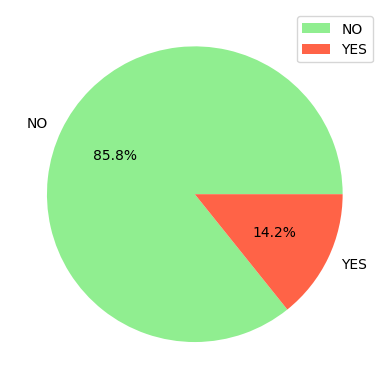

In [11]:
# Заменяем 1 и 0 на 'YES' и 'NO'
labels = train_data['loan_status'].replace({1: 'YES', 0: 'NO'})

# Уникальные значения для легенды
unique_labels = labels.unique()

# Настраиваем цвета
colors = ['lightgreen', 'tomato'] 

# Создаём круговую диаграмму
plt.pie(train_data['loan_status'].value_counts(), labels=unique_labels, autopct='%.1f%%', colors=colors)

# Добавляем легенду
plt.legend(unique_labels)

# Показываем график
plt.show()

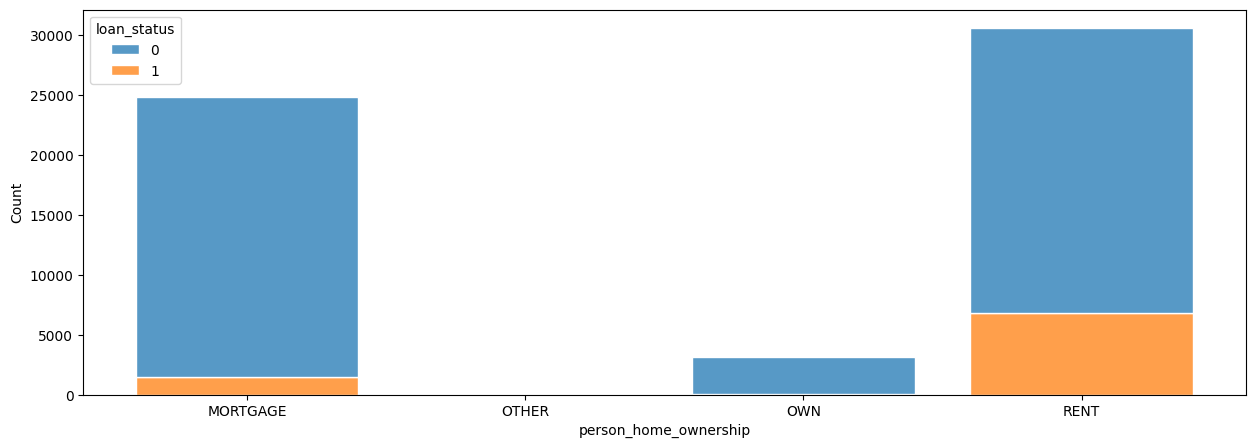

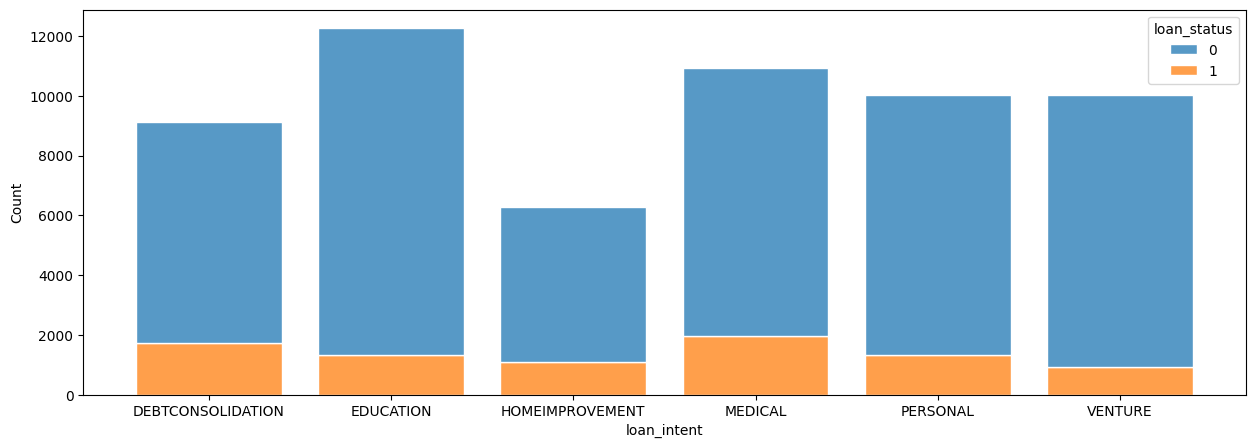

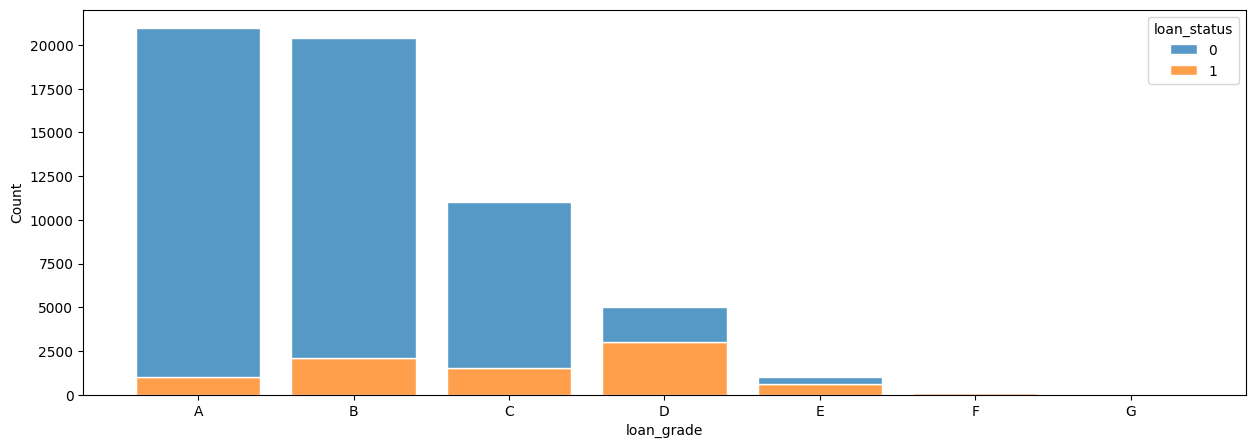

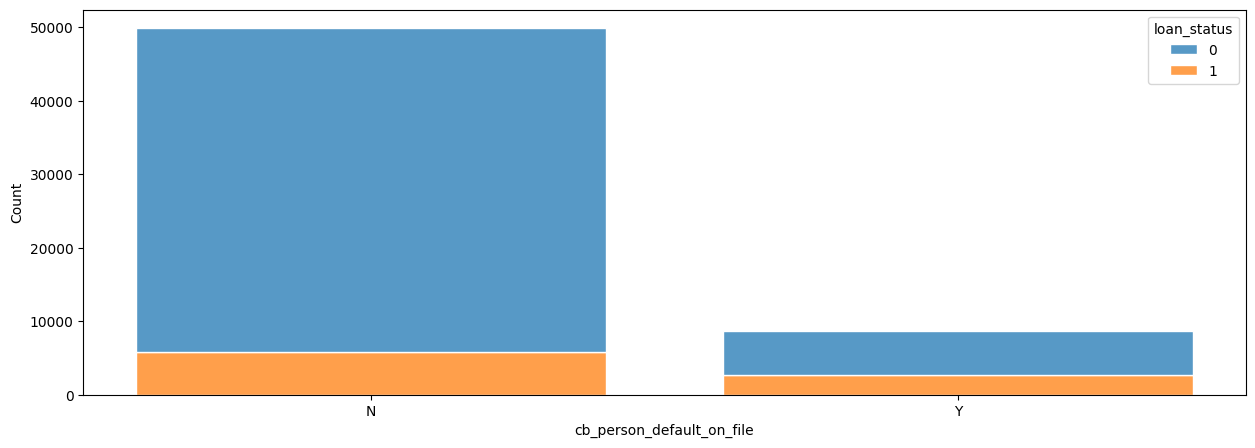

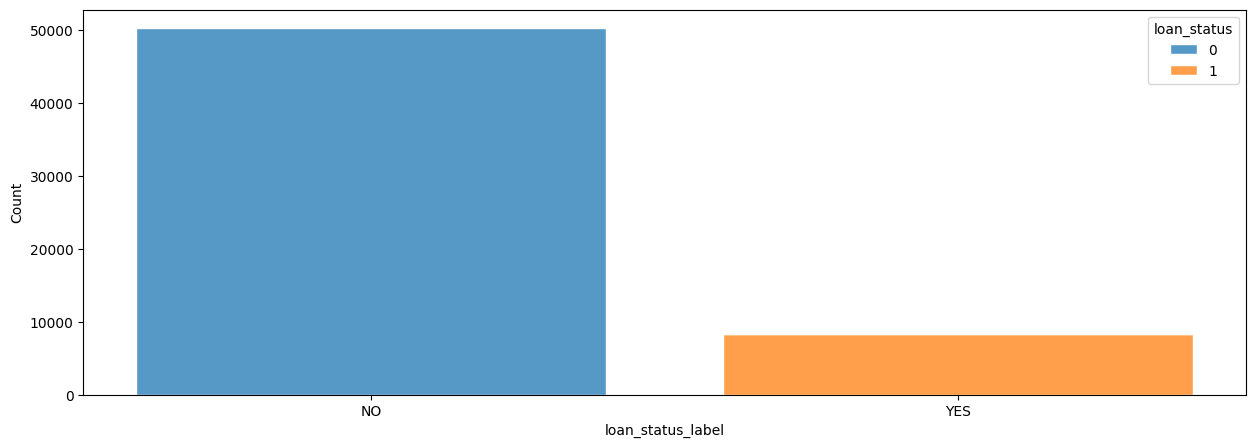

In [17]:
def plot_categorical_distributions(data, categorical_vars, target_col='loan_status'):
    for col in categorical_vars:
        if col == target_col:
            continue
        
        plt.figure(figsize=(15, 5))

        # Подсчет количества значений
        plot_data = data.groupby([col, target_col]).size().reset_index(name='count')

        sns.histplot(
            data=plot_data,
            x=col,
            weights='count',
            hue=target_col,
            multiple='stack',
            edgecolor='white',
            shrink=0.8
        )
        plt.show()

# Определяем категориальные переменные
categorical_var = train_data.select_dtypes(include=['object', 'category']).columns.tolist()

# Вызов функции для визуализации
plot_categorical_distributions(train_data, categorical_var)


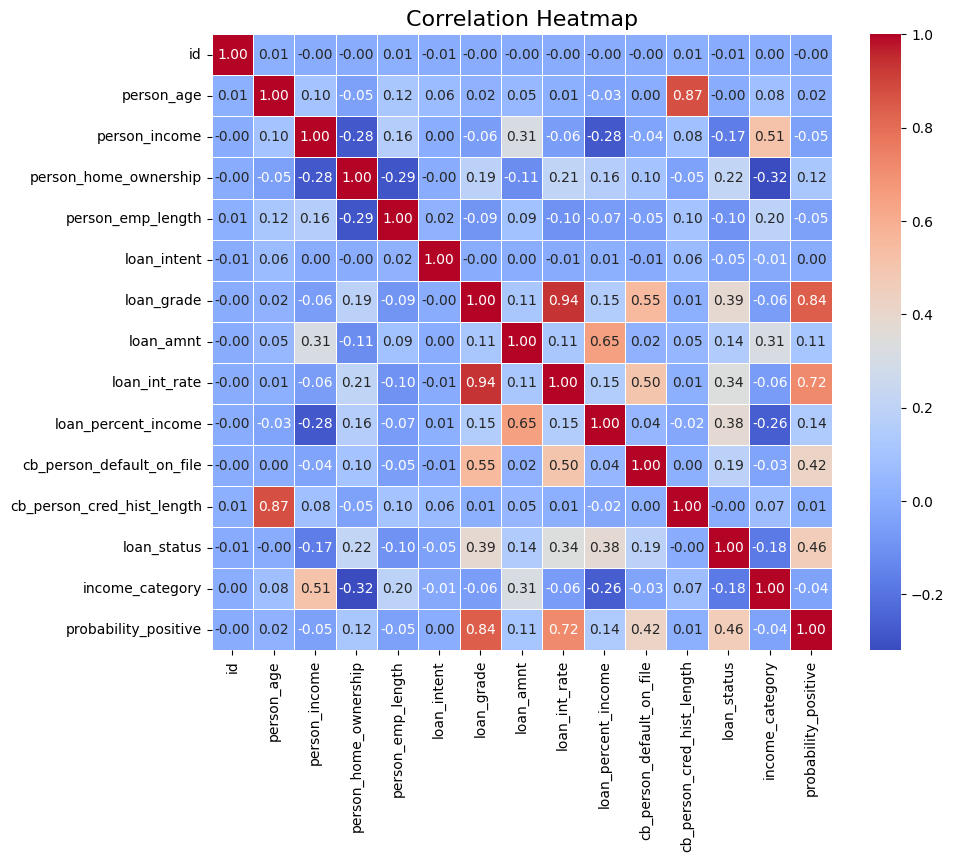

loan_status                   1.000000
probability_positive          0.461240
loan_grade                    0.385908
loan_percent_income           0.378280
loan_int_rate                 0.338948
person_home_ownership         0.220167
cb_person_default_on_file     0.186962
loan_amnt                     0.144982
person_age                   -0.001130
cb_person_cred_hist_length   -0.003030
id                           -0.008138
loan_intent                  -0.048751
person_emp_length            -0.100428
person_income                -0.169956
income_category              -0.178155
Name: loan_status, dtype: float64


In [18]:
Correlation = train_v3.corr()  
correlation_target = Correlation['loan_status'].sort_values(ascending=False)

# Create the heatmap
plt.figure(figsize=(10, 8))  
sns.heatmap(Correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

print(correlation_target)

In [19]:
# Подготовка датасета
train_df = train_v3
test_df = test_v3
target_column = 'loan_status'
drop_columns = ['loan_status']

# Целевая переменная и разбиение данные на train и тест
X = train_df.drop(columns=drop_columns)
y = train_df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучения моделей

### KNN

AUC-ROC Score: 0.90
Accuracy Score: 0.91

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95     10087
         1.0       0.76      0.53      0.62      1642

    accuracy                           0.91     11729
   macro avg       0.84      0.75      0.79     11729
weighted avg       0.90      0.91      0.90     11729



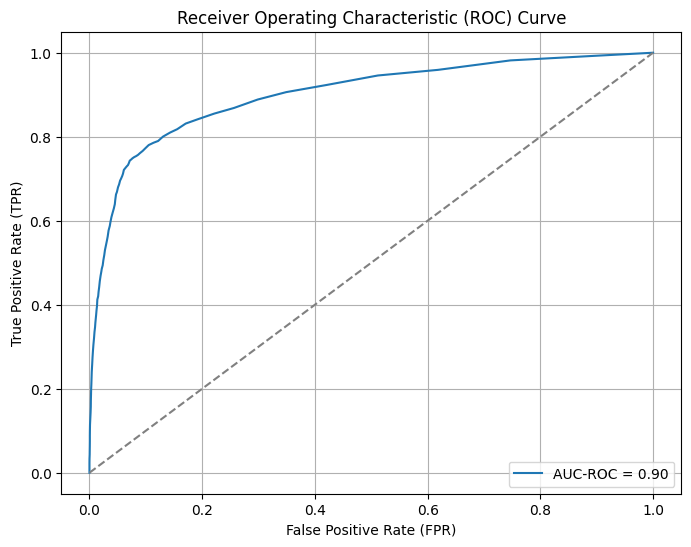


--- Test Set Predictions ---
   Predicted Probabilities  Predicted Values
0                     0.83               1.0
1                     0.10               0.0
2                     0.69               1.0
3                     0.02               0.0
4                     0.44               0.0
Test set predictions saved in test_knn_predictions.csv


In [24]:
# Масштабируем данные
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Применяем масштабирование к обучающим данным
X_test_scaled = scaler.transform(X_test)        # Применяем масштабирование к тестовым данным

# Настроим и обучим модель KNN
k = 100  # Количество соседей
knn_model = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='minkowski', p=2)
knn_model.fit(X_train_scaled, y_train)  # Обучаем модель на масштабированных обучающих данных

# Прогнозируем на тестовом наборе данных
y_pred = knn_model.predict(X_test_scaled)  # Прогнозируем метки классов
y_pred_prob = knn_model.predict_proba(X_test_scaled)[:, 1]  # Прогнозируем вероятности положительного класса

# Оценка модели
auc_score = roc_auc_score(y_test, y_pred_prob)  # Вычисляем AUC-ROC
print(f"AUC-ROC Score: {auc_score:.2f}")

accuracy = accuracy_score(y_test, y_pred)  # Вычисляем точность модели
print(f"Accuracy Score: {accuracy:.2f}")

# Выводим отчет о классификации
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Строим ROC-кривую
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)  # Получаем FPR и TPR для ROC-кривой
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC-ROC = {auc_score:.2f}")  # Строим ROC-кривую
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Линия случайных предсказаний
plt.xlabel("False Positive Rate (FPR)")  # Подпись оси X
plt.ylabel("True Positive Rate (TPR)")   # Подпись оси Y
plt.title("Receiver Operating Characteristic (ROC) Curve")  # Заголовок графика
plt.legend(loc="lower right")  # Легенда
plt.grid()  # Включаем сетку
plt.show()

# Прогнозируем на новом тестовом наборе данных (test_df)
X_test_new_scaled = scaler.transform(test_df[X_train.columns])  # Масштабируем новые тестовые данные
test_predictions_prob = knn_model.predict_proba(X_test_new_scaled)[:, 1]  # Прогнозируем вероятности
test_predictions = knn_model.predict(X_test_new_scaled)  # Прогнозируем метки классов

# Формируем вывод для тестовых данных
output_test = pd.DataFrame({
    'Predicted Probabilities': test_predictions_prob,
    'Predicted Values': test_predictions
})
print("\n--- Test Set Predictions ---")
print(output_test.head())

# Сохраняем прогнозы в CSV файл
output_test.to_csv("test_knn_predictions.csv", index=False)
print("Test set predictions saved in test_knn_predictions.csv")

### Logistic Regression

AUC-ROC Score: 0.89
Accuracy Score: 0.90

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.95     10087
         1.0       0.75      0.48      0.58      1642

    accuracy                           0.90     11729
   macro avg       0.83      0.72      0.76     11729
weighted avg       0.90      0.90      0.89     11729



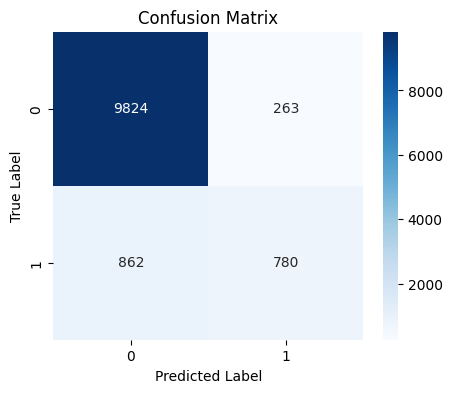

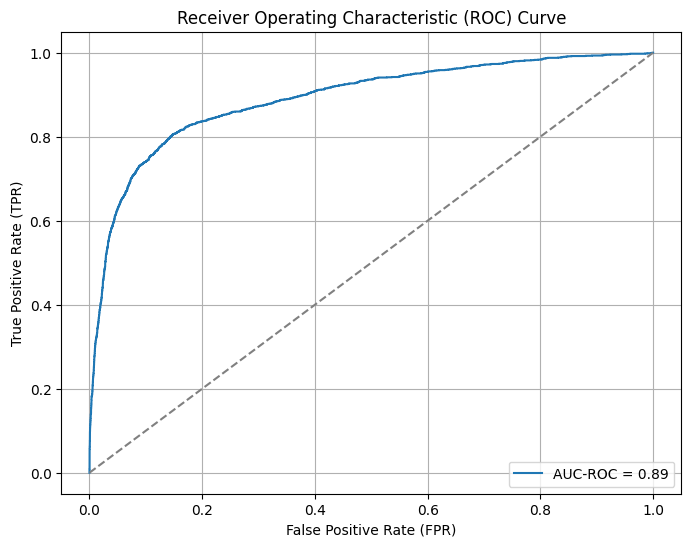


--- Test Set Predictions ---
   Predicted Probabilities  Predicted Values
0                 0.885374               1.0
1                 0.007951               0.0
2                 0.587396               1.0
3                 0.073181               0.0
4                 0.211780               0.0
Test set predictions saved in test_logistic_regression_predictions.csv


In [23]:
# Масштабирование данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение логистической регрессии
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Предсказания
y_pred = log_reg.predict(X_test_scaled)
y_pred_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# Оценка модели
auc_score = roc_auc_score(y_test, y_pred_prob)
accuracy = accuracy_score(y_test, y_pred)

print(f"AUC-ROC Score: {auc_score:.2f}")
print(f"Accuracy Score: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Матрица ошибок
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC-ROC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Предсказания на тестовом наборе
X_test_new_scaled = scaler.transform(test_df[X_train.columns])
test_predictions_prob = log_reg.predict_proba(X_test_new_scaled)[:, 1]
test_predictions = log_reg.predict(X_test_new_scaled)

# Сохранение предсказаний
output_test = pd.DataFrame({
    'Predicted Probabilities': test_predictions_prob,
    'Predicted Values': test_predictions
})
print("\n--- Test Set Predictions ---")
print(output_test.head())

output_test.to_csv("test_logistic_regression_predictions.csv", index=False)
print("Test set predictions saved in test_logistic_regression_predictions.csv")

### Decision Tree

Accuracy Score (Decision Tree): 0.91

Classification Report (Decision Tree):
              precision    recall  f1-score   support

         0.0       0.95      0.94      0.95     10087
         1.0       0.67      0.71      0.69      1642

    accuracy                           0.91     11729
   macro avg       0.81      0.83      0.82     11729
weighted avg       0.91      0.91      0.91     11729



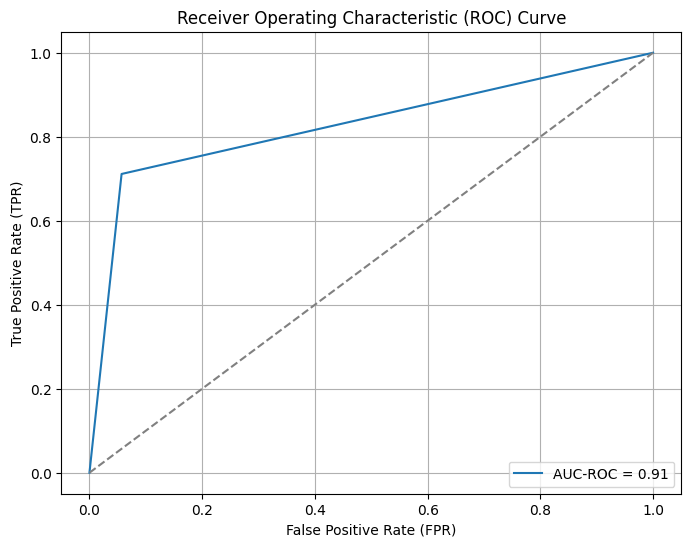


--- Test Set Predictions ---
   Predicted Probabilities  Predicted Values
0                      0.0               0.0
1                      0.0               0.0
2                      1.0               1.0
3                      0.0               0.0
4                      0.0               0.0
Test set predictions saved in test_dt_predictions.csv


In [27]:
# Масштабируем данные
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Применяем масштабирование к обучающим данным
X_test_scaled = scaler.transform(X_test)        # Применяем масштабирование к тестовым данным

# Настроим и обучим модель решающего дерева
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)  # Обучаем модель на масштабированных обучающих данных

# Прогнозируем на тестовом наборе данных
y_pred_dt = dt_model.predict(X_test_scaled)  # Прогнозируем метки классов

# Оценка модели
accuracy_dt = accuracy_score(y_test, y_pred_dt)  # Вычисляем точность модели
print(f"Accuracy Score (Decision Tree): {accuracy_dt:.2f}")

# Выводим отчет о классификации
print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))

# Строим ROC-кривую
fpr, tpr, _ = roc_curve(y_test, y_pred_dt)  # Получаем FPR и TPR для ROC-кривой
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC-ROC = {accuracy_dt:.2f}")  # Строим ROC-кривую
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Линия случайных предсказаний
plt.xlabel("False Positive Rate (FPR)")  # Подпись оси X
plt.ylabel("True Positive Rate (TPR)")   # Подпись оси Y
plt.title("Receiver Operating Characteristic (ROC) Curve")  # Заголовок графика
plt.legend(loc="lower right")  # Легенда
plt.grid()  # Включаем сетку
plt.show()

# Прогнозируем на новом тестовом наборе данных (test_df)
X_test_new_scaled = scaler.transform(test_df[X_train.columns])  # Масштабируем новые тестовые данные
test_predictions_prob = dt_model.predict_proba(X_test_new_scaled)[:, 1]  # Прогнозируем вероятности
test_predictions = dt_model.predict(X_test_new_scaled)  # Прогнозируем метки классов

# Формируем вывод для тестовых данных
output_test = pd.DataFrame({
    'Predicted Probabilities': test_predictions_prob,
    'Predicted Values': test_predictions
})
print("\n--- Test Set Predictions ---")
print(output_test.head())

# Сохраняем прогнозы в CSV файл
output_test.to_csv("test_dt_predictions.csv", index=False)
print("Test set predictions saved in test_dt_predictions.csv")

### Random Forest

Accuracy Score (Random Forest): 0.95

Classification Report (Random Forest):
              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97     10087
         1.0       0.92      0.70      0.79      1642

    accuracy                           0.95     11729
   macro avg       0.93      0.85      0.88     11729
weighted avg       0.95      0.95      0.95     11729



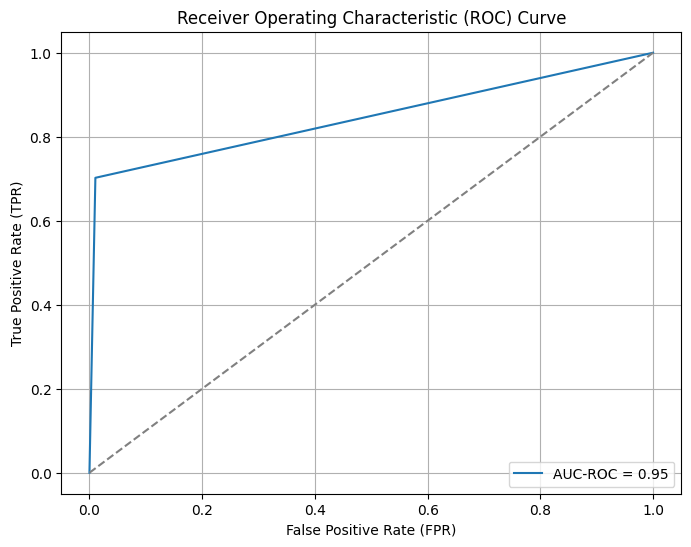


--- Test Set Predictions ---
   Predicted Probabilities  Predicted Values
0                     0.88               1.0
1                     0.07               0.0
2                     0.66               1.0
3                     0.04               0.0
4                     0.17               0.0
Test set predictions saved in test_rf_predictions.csv


In [28]:
# Масштабируем данные
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Применяем масштабирование к обучающим данным
X_test_scaled = scaler.transform(X_test)        # Применяем масштабирование к тестовым данным

# Настроим и обучим модель случайного леса
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)  # Обучаем модель на масштабированных обучающих данных

# Прогнозируем на тестовом наборе данных
y_pred_rf = rf_model.predict(X_test_scaled)  # Прогнозируем метки классов

# Оценка модели
accuracy_rf = accuracy_score(y_test, y_pred_rf)  # Вычисляем точность модели
print(f"Accuracy Score (Random Forest): {accuracy_rf:.2f}")

# Выводим отчет о классификации
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

# Строим ROC-кривую
fpr, tpr, _ = roc_curve(y_test, y_pred_rf)  # Получаем FPR и TPR для ROC-кривой
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC-ROC = {accuracy_rf:.2f}")  # Строим ROC-кривую
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Линия случайных предсказаний
plt.xlabel("False Positive Rate (FPR)")  # Подпись оси X
plt.ylabel("True Positive Rate (TPR)")   # Подпись оси Y
plt.title("Receiver Operating Characteristic (ROC) Curve")  # Заголовок графика
plt.legend(loc="lower right")  # Легенда
plt.grid()  # Включаем сетку
plt.show()

# Прогнозируем на новом тестовом наборе данных (test_df)
X_test_new_scaled = scaler.transform(test_df[X_train.columns])  # Масштабируем новые тестовые данные
test_predictions_prob = rf_model.predict_proba(X_test_new_scaled)[:, 1]  # Прогнозируем вероятности
test_predictions = rf_model.predict(X_test_new_scaled)  # Прогнозируем метки классов

# Формируем вывод для тестовых данных
output_test = pd.DataFrame({
    'Predicted Probabilities': test_predictions_prob,
    'Predicted Values': test_predictions
})
print("\n--- Test Set Predictions ---")
print(output_test.head())

# Сохраняем прогнозы в CSV файл
output_test.to_csv("test_rf_predictions.csv", index=False)
print("Test set predictions saved in test_rf_predictions.csv")

### CatBoost

0:	learn: 0.5648653	total: 65.4ms	remaining: 1m 5s
200:	learn: 0.1407301	total: 1.88s	remaining: 7.47s
400:	learn: 0.1231146	total: 3.66s	remaining: 5.47s
600:	learn: 0.1101609	total: 5.46s	remaining: 3.63s
800:	learn: 0.0999448	total: 7.31s	remaining: 1.81s
999:	learn: 0.0907222	total: 9.11s	remaining: 0us
Accuracy Score (CatBoost): 0.95

Classification Report (CatBoost):
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97     10087
         1.0       0.90      0.75      0.81      1642

    accuracy                           0.95     11729
   macro avg       0.93      0.87      0.89     11729
weighted avg       0.95      0.95      0.95     11729



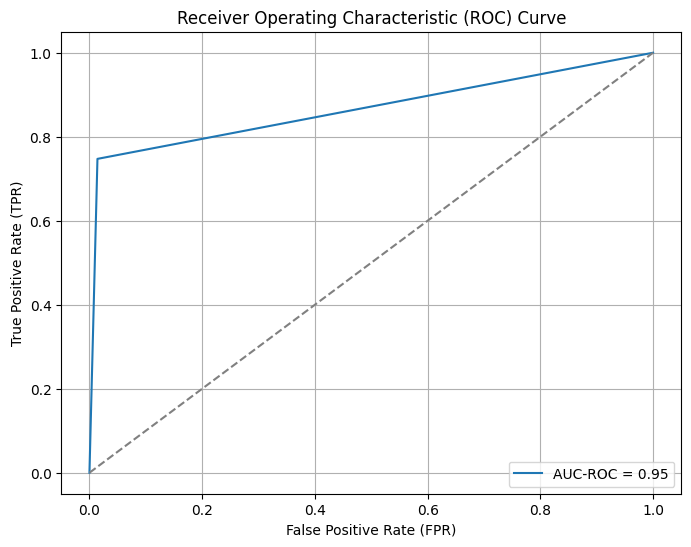


--- Test Set Predictions ---
   Predicted Probabilities  Predicted Values
0                 0.999048               1.0
1                 0.004419               0.0
2                 0.836678               1.0
3                 0.010218               0.0
4                 0.021079               0.0
Test set predictions saved in test_catboost_predictions.csv


In [29]:
# Масштабируем данные
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Применяем масштабирование к обучающим данным
X_test_scaled = scaler.transform(X_test)        # Применяем масштабирование к тестовым данным

# Настроим и обучим модель CatBoost
catboost_model = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=6, verbose=200)
catboost_model.fit(X_train_scaled, y_train)  # Обучаем модель на масштабированных обучающих данных

# Прогнозируем на тестовом наборе данных
y_pred_catboost = catboost_model.predict(X_test_scaled)  # Прогнозируем метки классов

# Оценка модели
accuracy_catboost = accuracy_score(y_test, y_pred_catboost)  # Вычисляем точность модели
print(f"Accuracy Score (CatBoost): {accuracy_catboost:.2f}")

# Выводим отчет о классификации
print("\nClassification Report (CatBoost):")
print(classification_report(y_test, y_pred_catboost))

# Строим ROC-кривую
fpr, tpr, _ = roc_curve(y_test, y_pred_catboost)  # Получаем FPR и TPR для ROC-кривой
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC-ROC = {accuracy_catboost:.2f}")  # Строим ROC-кривую
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Линия случайных предсказаний
plt.xlabel("False Positive Rate (FPR)")  # Подпись оси X
plt.ylabel("True Positive Rate (TPR)")   # Подпись оси Y
plt.title("Receiver Operating Characteristic (ROC) Curve")  # Заголовок графика
plt.legend(loc="lower right")  # Легенда
plt.grid()  # Включаем сетку
plt.show()

# Прогнозируем на новом тестовом наборе данных (test_df)
X_test_new_scaled = scaler.transform(test_df[X_train.columns])  # Масштабируем новые тестовые данные
test_predictions_prob = catboost_model.predict_proba(X_test_new_scaled)[:, 1]  # Прогнозируем вероятности
test_predictions = catboost_model.predict(X_test_new_scaled)  # Прогнозируем метки классов

# Формируем вывод для тестовых данных
output_test = pd.DataFrame({
    'Predicted Probabilities': test_predictions_prob,
    'Predicted Values': test_predictions
})
print("\n--- Test Set Predictions ---")
print(output_test.head())

# Сохраняем прогнозы в CSV файл
output_test.to_csv("test_catboost_predictions.csv", index=False)
print("Test set predictions saved in test_catboost_predictions.csv")

# Сравнение ROC-AUC моделей

0:	learn: 0.5648653	total: 11.3ms	remaining: 11.3s
200:	learn: 0.1407301	total: 1.86s	remaining: 7.39s
400:	learn: 0.1231146	total: 3.69s	remaining: 5.51s
600:	learn: 0.1101609	total: 5.58s	remaining: 3.7s
800:	learn: 0.0999448	total: 7.42s	remaining: 1.84s
999:	learn: 0.0907222	total: 9.28s	remaining: 0us


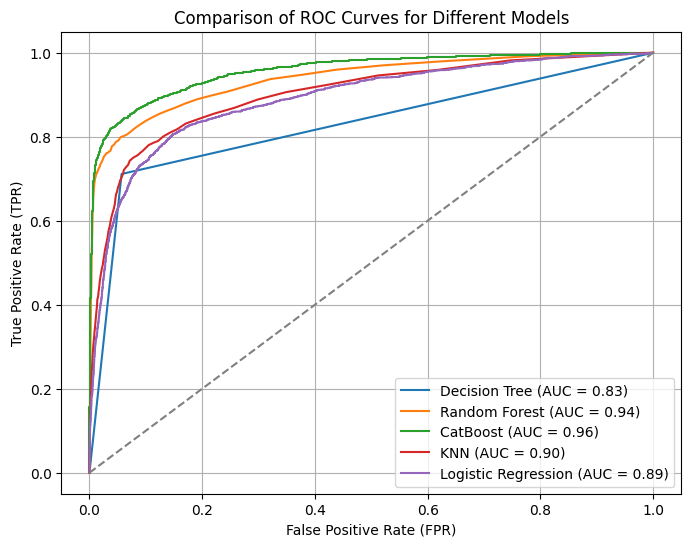

In [30]:
# Инициализация моделей
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'CatBoost': CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=6, verbose=200),
    'KNN': KNeighborsClassifier(n_neighbors=100, weights='uniform', metric='minkowski', p=2),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

# Создадим список для хранения AUC-ROC и FPR, TPR
plt.figure(figsize=(8, 6))

# Обучаем модели и строим ROC-кривые
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)  # Обучаем модель на масштабированных обучающих данных
    
    # Прогнозируем вероятности для тестового набора
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Вычисляем ROC-кривую
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    auc_score = roc_auc_score(y_test, y_pred_prob)  # Вычисляем AUC-ROC
    
    # Строим ROC-кривую на одном графике
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.2f})')

# Строим диагональную линию случайных предсказаний
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Оформляем график
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Comparison of ROC Curves for Different Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### В анализе рассматриваются следующие модели: Decision Tree (дерево решений), Random Forest (случайный лес), CatBoost, KNN (метод ближайших соседей) и Logistic Regression (логистическая регрессия). Для каждой модели указана площадь под кривой (AUC): Decision Tree — 0.83, Random Forest — 0.94, CatBoost — 0.96, KNN — 0.90, Logistic Regression — 0.89.

### На основании значений AUC можно сделать вывод, что модель CatBoost демонстрирует наивысшую производительность среди рассмотренных, так как её AUC составляет 0.96, что ближе всего к идеальному значению 1.0. За ней следуют Random Forest (AUC = 0.94), KNN (AUC = 0.90), Logistic Regression (AUC = 0.89) и Decision Tree (AUC = 0.83). Таким образом, CatBoost и Random Forest являются наиболее эффективными моделями в данном сравнении.